### 2D Diffusion
Modeling of 2D diffusion problems with a central difference discretisation.

In [1]:
from sympy import Eq, symbols, solve, diff, lambdify, Function

x, y, t, dt, dx, dy, v = symbols('x y t dt dx dy v')
u = symbols('u', cls=Function)

Start with the coninuous 2D diffusion equation.

In [2]:
continuous = Eq(diff(u(t, x, y), t), v*(diff(u(t, x, y), x, x) + diff(u(t, x, y), y, y)))
continuous

Eq(Derivative(u(t, x, y), t), v*(Derivative(u(t, x, y), (x, 2)) + Derivative(u(t, x, y), (y, 2))))

Discrestise the equation with a central difference scheme. Take the taylor expasion of the neighboring cells around the point u(t, x, y), u(t, x+1, y) and u(t, x-1, y). Terms after the third are ignored as they are negligibly small. Their sum gives an expression for the second order derivative.

In [3]:
x1 =  u(t, x, y) + dx*diff(u(t, x, y), x) + ((dx*dx)/2)*diff(u(t, x, y), x, x) + ((dx*dx*dx)/3)*diff(u(t, x, y), x, x, x)
x2 =  u(t, x, y) - dx*diff(u(t, x, y), x) + ((dx*dx)/2)*diff(u(t, x, y), x, x) - ((dx*dx*dx)/3)*diff(u(t, x, y), x, x, x)

central_diff = Eq(u(t, x+1, y) + u(t, x-1, y), x1 + x2)
central_diff

Eq(u(t, x - 1, y) + u(t, x + 1, y), dx**2*Derivative(u(t, x, y), (x, 2)) + 2*u(t, x, y))

Solve the equation for the second order derivative.

In [4]:
derivative = solve(central_diff, diff(u(t, x, y), x, x))[0]
derivative

(-2*u(t, x, y) + u(t, x - 1, y) + u(t, x + 1, y))/dx**2

The exact same process is used to obtain the expression for the neighboring cells in the y-axis. Substitue these expressions back into the continuous formula for x and y. Discretise the derivative of time normaly using the definition of a derivative.

In [5]:
discrete = Eq((u(t+1, x, y) - u(t, x, y))/dt, v*((-2*u(t, x, y) + u(t, x-1, y) + u(t, x+1, y))/(dx*dx) + (-2*u(t, x, y) + u(t, x, y-1) + u(t, x, y+1))/(dy*dy)))
discrete

Eq((-u(t, x, y) + u(t + 1, x, y))/dt, v*((-2*u(t, x, y) + u(t, x, y - 1) + u(t, x, y + 1))/dy**2 + (-2*u(t, x, y) + u(t, x - 1, y) + u(t, x + 1, y))/dx**2))

Solve for u(t+1, x, y) to allow the advancement of time.

In [6]:
solution = solve(discrete, u(t+1, x, y))[0]
update = lambdify([dx, dy, dt, v, u(t, x, y), u(t, x+1, y), u(t, x-1, y), u(t, x, y+1), u(t, x, y-1)], solution)
solution

(dt*dx**2*v*(-2*u(t, x, y) + u(t, x, y - 1) + u(t, x, y + 1)) + dt*dy**2*v*(-2*u(t, x, y) + u(t, x - 1, y) + u(t, x + 1, y)) + dx**2*dy**2*u(t, x, y))/(dx**2*dy**2)

Run the simulation with this equation, as done in 2d-convection.ipynb

In [7]:
import numpy as np
import matplotlib.pyplot as plt

width = 30
height = 30
nu = width*height

dx = 1
dy = 1
dt = 0.08

def initial_conditions():
    u = np.ones(shape=(width, height))
    for x in range(width):
        for y in range(height):
            if (x > width/4 and x < 3*width/4) and (y > height/4 and y < 3*height/4):
                u[x][y] = 2
    return u

u = initial_conditions()

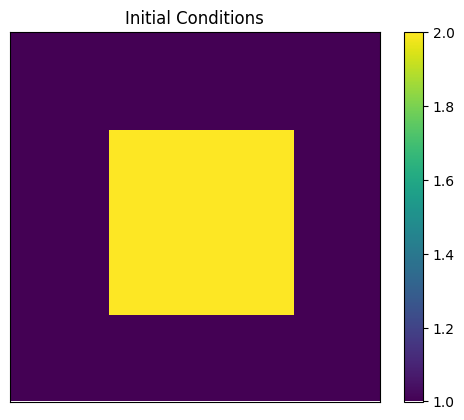

In [8]:
def plot(u, title=None):
    plt.imshow(u)
    plt.yticks([])
    plt.xticks([])
    plt.title(title)
    plt.colorbar()
    plt.show()

plot(u, title="Initial Conditions")

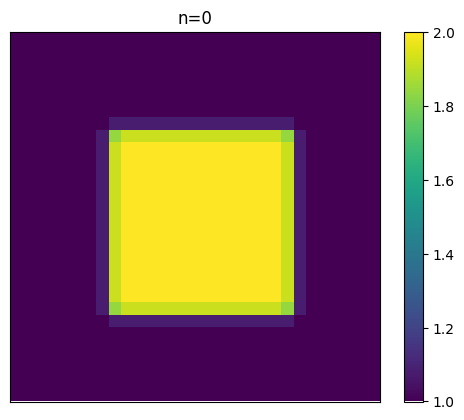

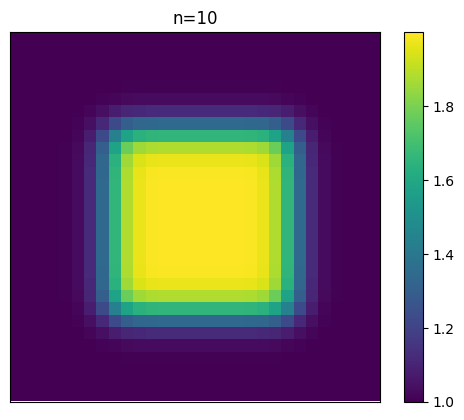

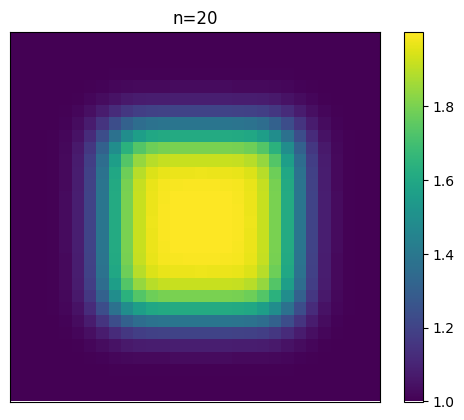

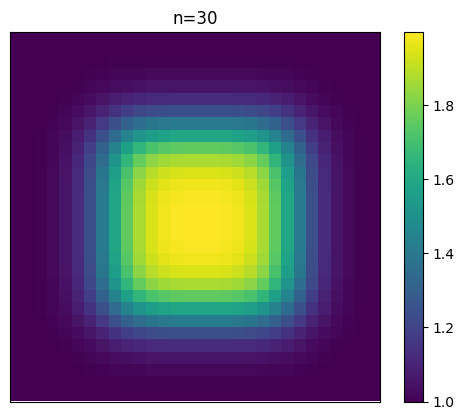

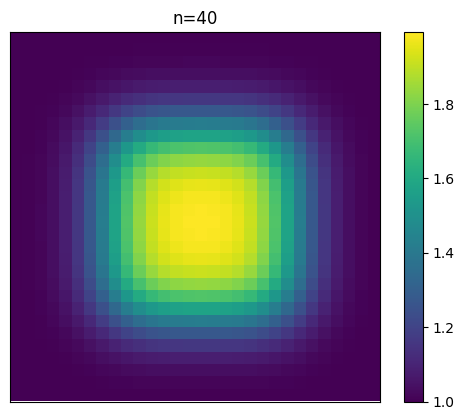

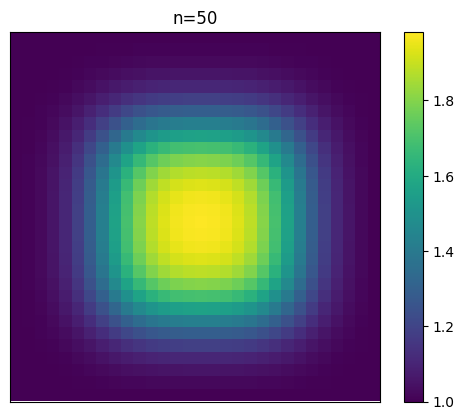

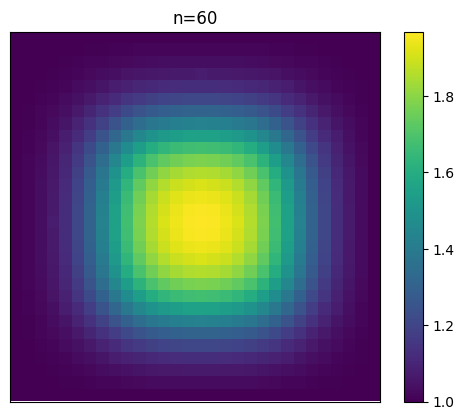

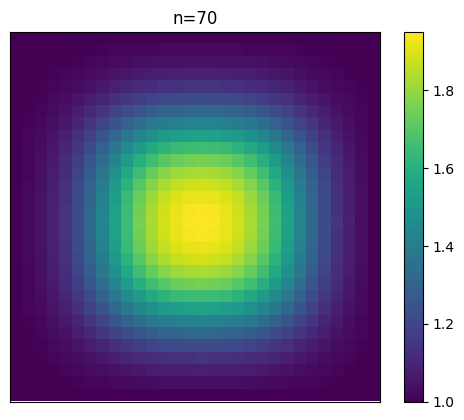

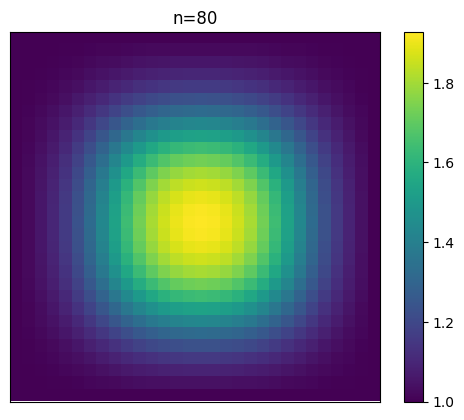

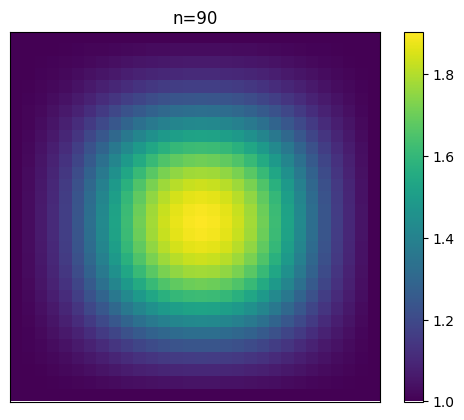

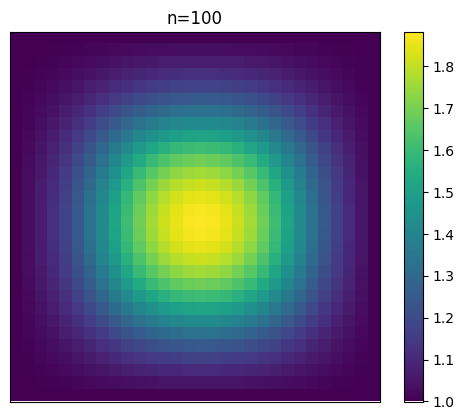

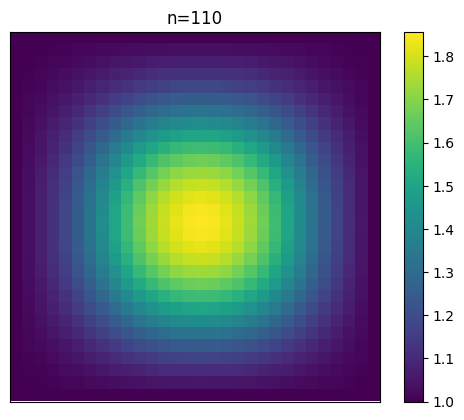

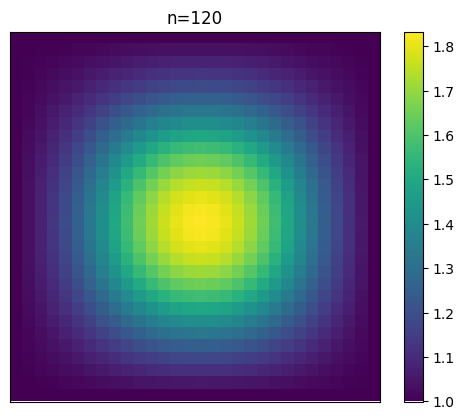

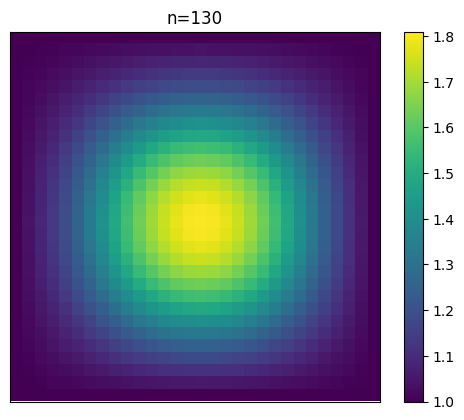

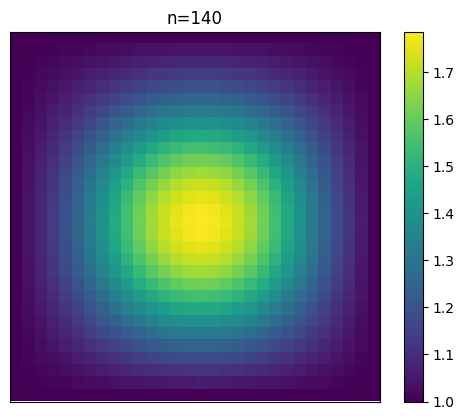

In [9]:
def diffuse(nt, v):
    u = initial_conditions()
    for n in range(nt):
        un = u.copy()
        for x in range(1, width-1):
            for y in range(1, height-1):
                u[x][y] = update(dx, dy, dt, v, un[x][y], un[x+1][y], un[x-1][y], un[x][y+1], un[x][y-1])

        if n % 10 == 0:
            plot(u, title=f"n={n}")

diffuse(150, 1)